In [ ]:
# Install all necessary packages (might take a minute)
!pip install pandas openpyxl fpdf pymupdf spacy nltk scikit-learn sentence-transformers pyecharts matplotlib --quiet

# Download NLTK stopwords and spaCy English model
import nltk
nltk.download('stopwords')
import spacy
spacy.cli.download("en_core_web_sm")


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.1/24.1 MB 65.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.9/153.9 kB 10.1 MB/s eta 0:00:00


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
from google.colab import files

print("Upload utils.py, Courses.py, and one or more resume PDFs or a CSV/XLSX of candidates.")
uploaded = files.upload()


Upload utils.py, Courses.py, and one or more resume PDFs or a CSV/XLSX of candidates.


Saving DamariGrantResume.pdf to DamariGrantResume.pdf


In [ ]:
# Import your utility modules
import importlib.util

def load_module(filename, module_name):
    spec = importlib.util.spec_from_file_location(module_name, filename)
    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)
    return module

utils = load_module('utils.py', 'utils')
Courses = load_module('Courses.py', 'Courses')


Loading Semantic Model (Sentence-Transformers)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Semantic Model Loaded successfully.
Loading spaCy model in utils...
spaCy loaded in utils!


In [ ]:
import pandas as pd
import os

# Attempt to load candidate data from CSV/XLSX
if 'example_data.csv' in uploaded:
    df = pd.read_csv('example_data.csv')
elif 'example_data.xlsx' in uploaded:
    df = pd.read_excel('example_data.xlsx')
else:
    # Parse uploaded PDFs (if any)
    pdf_files = [f for f in uploaded if f.lower().endswith('.pdf')]
    rows = []
    for pdf_filename in pdf_files:
        pdf_raw_text, page_count = utils.pdf_reader(pdf_filename)
        pdf_clean_text = utils.clean_text_nltk(pdf_raw_text)
        basic_data = utils.extract_resume_data(pdf_raw_text, pdf_clean_text)
        sections = utils.parse_resume_sections(pdf_raw_text)
        reco_field = utils.predict_field_fast(pdf_clean_text)
        score_data = utils.calculate_rigorous_score(
            resume_text=pdf_raw_text,
            resume_edu_section=sections.get('Education', ''),
            resume_exp_section=sections.get('Experience', ''),
            user_skills=basic_data.get('skills', []),
            job_description_text=Courses.JOB_DESCRIPTIONS.get('default', '')
        )
        rows.append({
            'Name': basic_data.get('name'),
            'Email': basic_data.get('email'),
            'Field': reco_field,
            'Score': score_data['total_score'],
            'Skills': ', '.join(basic_data.get('skills', [])),
        })
    df = pd.DataFrame(rows)

# Show the first few rows for inspection
df.head()


,Name,Email,Field,Score,Skills
0,New NY,damari.grant@example.com,Mobile Development,60.3,"git, version control, javascript, react, html,..."


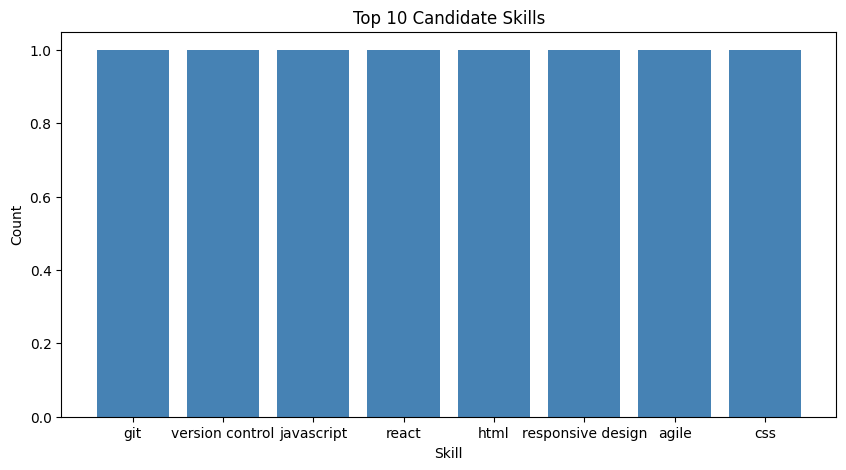

In [ ]:
from collections import Counter
import matplotlib.pyplot as plt

skills_flat = []
for val in df['Skills']:
    skills_flat += [s.strip().lower() for s in val.split(',') if s.strip()]

top_skills = Counter(skills_flat).most_common(10)
skill_names = [s[0] for s in top_skills]
skill_counts = [s[1] for s in top_skills]

plt.figure(figsize=(10,5))
plt.bar(skill_names, skill_counts, color="steelblue")
plt.title("Top 10 Candidate Skills")
plt.xlabel("Skill")
plt.ylabel("Count")
plt.show()


In [ ]:
df.sort_values(by="Score", ascending=False)[["Name", "Email", "Field", "Score", "Skills"]].head(10)


,Name,Email,Field,Score,Skills
0,New NY,damari.grant@example.com,Mobile Development,60.3,"git, version control, javascript, react, html,..."


In [ ]:
from pyecharts import options as opts
from pyecharts.charts import Bar

bar = (
    Bar()
    .add_xaxis(skill_names)
    .add_yaxis("Skill Count", skill_counts)
    .set_global_opts(title_opts=opts.TitleOpts(title="Skills Gap (Echarts)"))
)
bar.render_notebook()


In [ ]:
from pyecharts import options as opts
from pyecharts.charts import Bar

bar = (
    Bar()
    .add_xaxis(skill_names)
    .add_yaxis("Skill Count", skill_counts)
    .set_global_opts(title_opts=opts.TitleOpts(title="Skills Gap (Echarts)"))
)
bar.render_notebook()


# Next Steps

- Upload more resumes or CSV/XLSX files to see richer analytics.
- Try expanding with pie charts, scatter plots, or semantic similarity from `utils.py`.
- All visualization and analytics run entirely in Colab; Flask/DB/Celery are not necessary for demo.
